In [1]:
1+1

2

ReAct Agent Architecture

Aim

This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

C:\Users\tejas\AppData\Local\Temp\ipykernel_19712\1871147362.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
from langchain.tools import tool
import arxiv

@tool
def search_arxiv(query: str) -> str:
    """Search papers from Arxiv."""

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance
    )

    results = []

    for paper in client.results(search):
        results.append(
            f"Title: {paper.title}\n"
            f"Summary: {paper.summary[:500]}"
        )

    return "\n\n".join(results)

print(search_arxiv.invoke("Attention is all you need"))

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a

Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponential g

In [5]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wiki.name)

wikipedia


In [6]:
wiki.invoke("What is Machine Learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from pre-trained data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical opt'

In [7]:
from dotenv import load_dotenv
import os 
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true" 
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [48]:
### Custom Functions
from langchain_core.tools import tool

@tool
def multiply(a:str, b:str) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) * int(b)


# This will be a tool
@tool
def add(a:str, b:str) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) + int(b)

@tool
def divide(a:str,b:str)-> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) / int(b) 

tools = [search_arxiv,wiki,add,multiply,divide]

In [49]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()


In [50]:
tavily.invoke("Provide me recent AI news for June 7 2026")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': 'Telecoms Tech News\n\nJune 5, 2026\n\n## Geely taps Vodafone private 5G for automotive IoT\n\nAI News\n\nJune 5, 2026\n\n## How C3 AI agents will automate predictive maintenance for Shell\n\nInternet of Things News\n\nJune 5, 2026\n\n## Shell expands predictive maintenance programme with C3 AI\n\nAI News\n\nJune 4, 2026\n\n## Meta Business Agent drives AI-powered conversational commerce\n\n## Subscribe\n\nAll our premium content and latest tech news delivered straight to your inbox\n\n## Explore\n\n## Reach Our Audience\n\n## Categories\n\n## Other Publications\n\nAI News is part of TechForge\n\n## Subscribe\n\nAll our premium content and latest tech news delivered straight to your inbox [...] Inside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK 

In [51]:
### Combine all the tools in the list
tools = [tavily,search_arxiv,wiki,add,multiply,divide]

In [52]:
## Intialize LLM model
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm_with_tools = llm.bind_tools(tools)

In [53]:
from pprint import pprint
from langchain_core.messages import HumanMessage , AIMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'd4zxdg09g',
  'type': 'tool_call'}]

In [54]:
## State Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

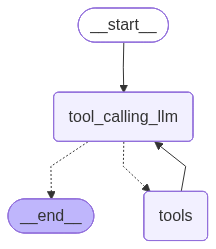

In [55]:
### Entire Chatbot with Langgraph
from langgraph.graph import StateGraph,START,END 
from IPython.display import display,Image
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")

graph_builder = builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [56]:
messages = graph_builder.invoke(
    {
        "messages": HumanMessage(
            content="Provide me the recent AI news, add 5 plus 5 the multiply by 3"
        )
    }
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the recent AI news, add 5 plus 5 the multiply by 3
================================== Ai Message ==================================

Recent AI news:
Tool Calls:
  tavily_search_results_json (h2xnpzt9j)
 Call ID: h2xnpzt9j
  Args:
    query: recent AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Google AI announcements from April 2026", "url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-april-2026", "content": "## Bullet points\n\n Check out \"The latest AI news we announced in April\" for Google's newest tech updates.\n Google Cloud introduced powerful new tools and chips to help businesses build AI agents.\n You can now create professional videos for free using the new Google Vids suite.\n New coding tools like Learn Mode in Colab act as your personal programming tutor.\n Google is

### Agent Memory


In [57]:
messages=graph_builder.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (4ggnq2zw1)
 Call ID: 4ggnq2zw1
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The result of 5 plus 8 is 13.


In [58]:
messages = [HumanMessage(content="Divide that by 5")]
messages=graph_builder.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (w8ngnm5q3)
 Call ID: w8ngnm5q3
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: divide

2.0
================================== Ai Message ==================================

2.0


#### Memory Saver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

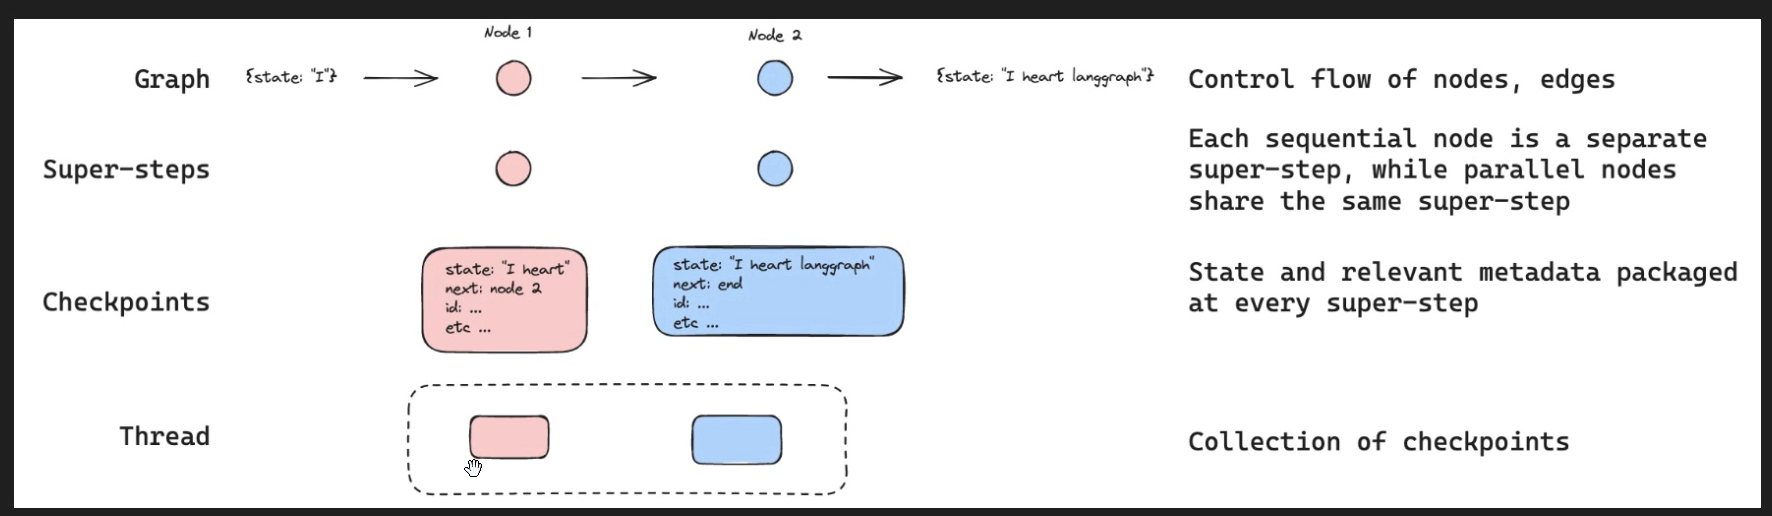

In [59]:
### Entire Chatbot with Langgraph
from langgraph.graph import StateGraph,START,END 
from IPython.display import display,Image
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")



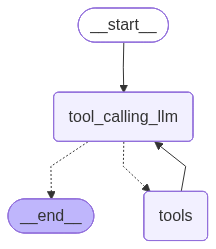

In [60]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)


display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [61]:
## Specify the thread
config = {"configurable":{"thread_id":"1"}}

## Specify the input
messages = [HumanMessage(content="Add 12 and 13")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13
================================== Ai Message ==================================
Tool Calls:
  add (2pddnfd2q)
 Call ID: 2pddnfd2q
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The result of adding 12 and 13 is 25.


In [62]:
messages = [HumanMessage(content="Add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13
================================== Ai Message ==================================
Tool Calls:
  add (2pddnfd2q)
 Call ID: 2pddnfd2q
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The result of adding 12 and 13 is 25.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (v5ekqp8dk)
 Call ID: v5ekqp8dk
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The result of adding 25 and 25 is 50.
